In [2]:
def bayes(prior, sensitivity, false_positive_rate):
    # P(disease | positive test)
    p_positive = (sensitivity * prior) + (false_positive_rate * (1 - prior))
    posterior = (sensitivity * prior) / p_positive
    return posterior

# Disease affects 1 in 10,000 people
prior = 1/10000
sensitivity = 0.99       # true positive rate
false_positive_rate = 0.01  # 1% chance of wrong positive

result = bayes(prior, sensitivity, false_positive_rate)
print(f"Probability you actually have the disease: {result:.2%}")

Probability you actually have the disease: 0.98%


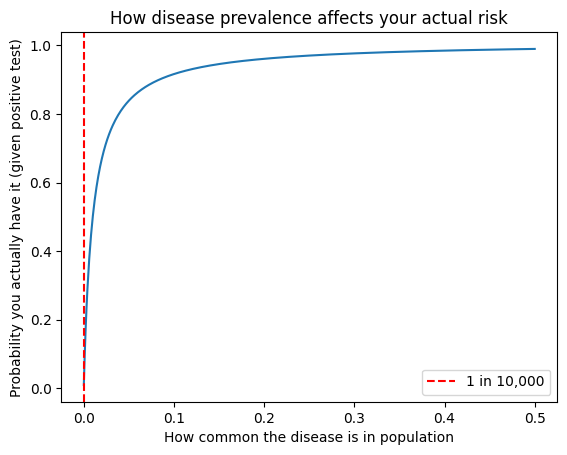

In [3]:
import numpy as np
import matplotlib.pyplot as plt

priors = np.linspace(0.0001, 0.5, 500)
results = [bayes(p, 0.99, 0.01) for p in priors]

plt.plot(priors, results)
plt.title('How disease prevalence affects your actual risk')
plt.xlabel('How common the disease is in population')
plt.ylabel('Probability you actually have it (given positive test)')
plt.axvline(1/10000, color='red', linestyle='--', label='1 in 10,000')
plt.legend()
plt.show()

## What I learned — Bayes Theorem

Before the test, I knew the disease only affects 1 in 10,000 people.
That prior belief is so strong that even a 99% accurate positive result 
is probably a false alarm — because true cases are so rare.

In trading, the same logic applies. A strategy can look 99% accurate 
in backtests, but if genuine profitable opportunities are rare, 
most of its signals will still be false positives in live markets.

Bayes theorem teaches us that accuracy alone means nothing 
without knowing how common the thing you're detecting actually is.

In [4]:
import numpy as np

def monty_hall(switch, simulations=100000):
    wins = 0
    for _ in range(simulations):
        # Randomly place the car
        car = np.random.randint(0, 3)
        # Contestant picks a door
        pick = np.random.randint(0, 3)
        
        if switch:
            # Host reveals a goat, contestant switches
            # Switching wins if original pick was wrong
            if pick != car:
                wins += 1
        else:
            # Staying wins if original pick was right
            if pick == car:
                wins += 1
    
    return wins / simulations

stay_wins = monty_hall(switch=False)
switch_wins = monty_hall(switch=True)

print(f"Win rate if you STAY:   {stay_wins:.2%}")
print(f"Win rate if you SWITCH: {switch_wins:.2%}")

Win rate if you STAY:   32.85%
Win rate if you SWITCH: 66.76%


## Monty Hall Problem

I picked door 1. The host revealed door 3 has a goat.
My gut said stay with door 1 — 50/50 chance right?

Wrong. The simulation proved that switching to door 2 
wins 2/3 of the time, and staying only wins 1/3 of the time.

Why? Because when I first picked door 1, I only had a 1/3 chance 
of being right. That means 2/3 of the time the car is behind 
the other remaining door. The host revealing a goat doesn't 
change my original odds — it just shows me where to switch.

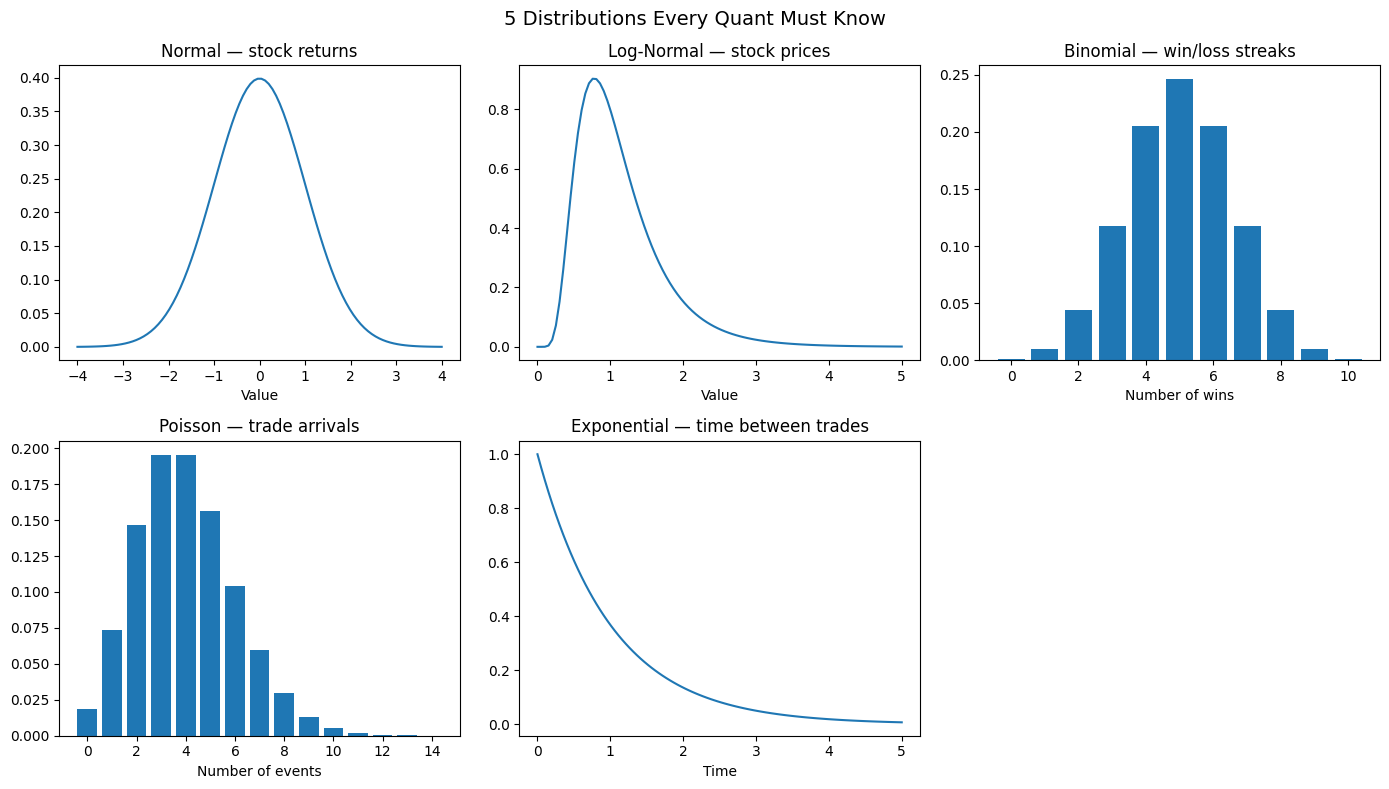

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('5 Distributions Every Quant Must Know', fontsize=14)

# 1. Normal Distribution
x = np.linspace(-4, 4, 100)
axes[0,0].plot(x, stats.norm.pdf(x, 0, 1))
axes[0,0].set_title('Normal — stock returns')
axes[0,0].set_xlabel('Value')

# 2. Log-Normal Distribution
x = np.linspace(0, 5, 100)
axes[0,1].plot(x, stats.lognorm.pdf(x, s=0.5))
axes[0,1].set_title('Log-Normal — stock prices')
axes[0,1].set_xlabel('Value')

# 3. Binomial Distribution
n, p = 10, 0.5
x = np.arange(0, 11)
axes[0,2].bar(x, stats.binom.pmf(x, n, p))
axes[0,2].set_title('Binomial — win/loss streaks')
axes[0,2].set_xlabel('Number of wins')

# 4. Poisson Distribution
x = np.arange(0, 15)
axes[1,0].bar(x, stats.poisson.pmf(x, mu=4))
axes[1,0].set_title('Poisson — trade arrivals')
axes[1,0].set_xlabel('Number of events')

# 5. Exponential Distribution
x = np.linspace(0, 5, 100)
axes[1,1].plot(x, stats.expon.pdf(x, scale=1))
axes[1,1].set_title('Exponential — time between trades')
axes[1,1].set_xlabel('Time')

axes[1,2].axis('off')

plt.tight_layout()
plt.show()